In [1]:
import sys
import git
import pathlib

# Set up the PROJ_ROOT variable
PROJ_ROOT_PATH = pathlib.Path(git.Repo('.', search_parent_directories=True).working_tree_dir)
PROJ_ROOT =  str(PROJ_ROOT_PATH)
if PROJ_ROOT not in sys.path:
    sys.path.append(PROJ_ROOT)

# Explicitly add the current notebook's directory
CURRENT_DIR = str(pathlib.Path().absolute())
if CURRENT_DIR not in sys.path:
    sys.path.insert(0, CURRENT_DIR)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors
%matplotlib inline  

# Baseline Figures Comparison

In [3]:
# Experiment Name and Locations
exp_1 = "tf-tc-delft-hemt-lp_mn-kide"
fname1 = PROJ_ROOT_PATH / "notebooks" / "experiments" / "baseline" / exp_1 / f"{exp_1}.pkl"
df_1 =  pd.read_pickle(fname1)
pq_1 = [1616, 9186, 5303, 7901]
title_1 = "a) TF-TC (Cri/oFlex Wiring)"

exp_2 = "tf-tc-hdw-hemt-lp_mn-kide"
fname2 = PROJ_ROOT_PATH / "notebooks" / "experiments" / "baseline" / exp_2 / f"{exp_2}.pkl"
df_2 =  pd.read_pickle(fname2)
pq_2 = [3919, 8367, 1193, 1482]
title_2 = "b) TF-TC (High Density Wiring)"

In [4]:
from library.utils import fontstyle, style_map

title_font, axis_label_font, tick_label_font, legend_font, text_font = fontstyle

# Define fallbacks (only used if a stack tuple isn’t in style_map)
# fallback_colors = plt.cm.tab20.colors  # a nice, long qualitative palette
# fallback_hatches = ['/', '\\', 'x', '-', '+', 'o', 'O', '.', '*']  # repeats cyclically
fallback_color = 'white' 
fallback_hatch = '//'  

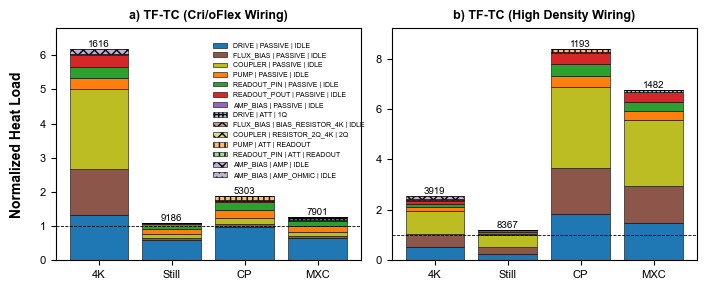

In [6]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(7.16, 3))

for (ax, df_plot, possible_physical_qubits, title) in zip([axs[0], axs[1]], [df_1, df_2], [pq_1, pq_2], [title_1, title_2]):
    # ax = ax[0,0]
    # df_plot = df_1
    # possible_physical_qubits = pq_1
    
    # Columns: MultiIndex with levels (Cable, Component, Operation)
    cols = list(df_plot.columns)
    
    # Index: temperature stages (e.g., "4K", "Still", "CP", "MXC")
    # X positions and labels (temperature stages)
    x = np.arange(len(df_plot.index))
    xticklabels = ["4K", "Still", "CP", "MXC" ]
    
    # Create the figure/axes
    
    # Build the stacked bars
    bottom = np.zeros(len(x), dtype=float)
    
    for i, col in enumerate(cols):
        values = df_plot[col].astype(float).values
    
        # pull style from style_map if present, else fallback
        style = style_map.get(col, {})
        color = style.get('color', fallback_color)
        hatch = style.get('hatch', fallback_hatch)
    
        # readable label in legend
        label = f"{col[0]} | {col[1]} | {col[2]}"
    
        bars = ax.bar(
            x,
            values,
            bottom=bottom,
            label=label,
            color=color,
            edgecolor='black',
            linewidth=0.4
        )
        # apply hatch to each rectangle
        for b in bars:
            b.set_hatch(hatch)
    
        bottom += values  # update stack baseline
    
    
    # Display no. of supported qubits on top of the bar
    totals = df_plot.sum(axis=1)  # Sum over column. Get bar height
    for i, total in enumerate(totals):
        ax.text(i, total, f'{possible_physical_qubits[i]}', ha='center', va='bottom', fontproperties=text_font)
    
    # Draw horizantal line at y=1
    ax.axhline(y=1, color='k', linestyle='--',linewidth=0.6)
    
    # Axis cosmetics
    # Set titles 
    ax.set_title(title, fontproperties=axis_label_font)
    # ax.set_xlabel("Temperature Stage", fontproperties=axis_label_font)
    # ax.set_ylabel("Normalized Heat Load", fontproperties=axis_label_font)
    ax.set_xticks(x)
    ax.set_xticklabels(xticklabels, fontproperties=tick_label_font, rotation=0)
    for label in ax.get_yticklabels() :
        label.set_fontproperties(tick_label_font)
    ax.set_ylim(0, max(totals)*1.1) # Set max y-value to be slightly higher than the tallest bar

# Legend
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels,
          ncol=1, 
          bbox_to_anchor=(0.3,0.85), 
          loc='upper left',
          prop=legend_font,
          frameon=False,
          borderaxespad=0.)

# Axis Labels
# fig.supxlabel('Temperature Stage',fontproperties=title_font)
fig.supylabel('Normalized Heat Load', fontproperties=title_font)

# Adjust layout to prevent labels from overlapping
plt.tight_layout()

# Save figure
plt.savefig(f"./crioflex-hdw.png",dpi=600)